# カヤノ農産：予測モデル作成
- model_kayano.ipynbで作成したモデル学習用データセットを使う

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pycaret.regression import *
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
### 変数設定 ###
#--ファイル
farm_list = "farm/kayano_farm.csv"
farm_data = "farm/kayano_data.csv"
harvest_file = "farm/kayano_harvest_date.csv"
weather_file = "weather/kayano/weather_{}.csv"
model_data1 = "farm/kayano_model_data1.csv"
model_data2 = "farm/kayano_model_data2.csv"

## モデル学習（一番茶）
- PyCaretを用いたMLモデルの学習を行う

In [3]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data1)

#--茶の場合は一番茶・二番茶ともに2025年を含めて3年分しか無いため、CVをするためには2024年をテストデータにできない
# #--2024年をテストデータとする場合、2025年は除外しておく
# df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [4]:
#--全ての年度に共通する品種を抽出
exist_kind = (df_ml
    .groupby('品種')['年度']
    .nunique()
    .loc[lambda x: x == df_ml['年度'].nunique()]
    .index
    .tolist()
)
print(f'全年度共通の品種数: {len(exist_kind)}')
print(f'品種リスト: {exist_kind}')

全年度共通の品種数: 8
品種リスト: ['おくひかり', 'おくみどり', 'おくゆたか', 'さやまかおり', 'つゆひかり', 'ふうしゅん', 'めいりょく', 'やぶきた']


In [5]:
### 追加の前処理 ###
#--すべての年度に存在する品種のみを対象とする
# （一番茶はすべて該当するが、二番茶は該当しない品種がある）
df_ml = df_ml.query("品種 in @exist_kind").reset_index(drop=True)

#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
# test_year = 2024
test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['品種','圃場名','年度'])
        .groupby('品種')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['品種','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日数']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [ ]:
### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 
    'TMP_mea', 'APCPRA', 'GSR', 'TMP_GDD0', 'TMP_GDD10', 'TmulGSR', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'GSR_05', 'TMP_GDD0_05', 'TMP_GDD10_05', 'TmulGSR_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'GSR_10', 'TMP_GDD0_10', 'TMP_GDD10_10', 'TmulGSR_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'GSR_15', 'TMP_GDD0_15', 'TMP_GDD10_15', 'TmulGSR_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'GSR_20', 'TMP_GDD0_20', 'TMP_GDD10_20', 'TmulGSR_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'GSR_25', 'TMP_GDD0_25', 'TMP_GDD10_25', 'TmulGSR_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'GSR_30', 'TMP_GDD0_30', 'TMP_GDD10_30', 'TmulGSR_30', 'RA_days_30',
    'TMP_mea_jan', 'TMP_mea_feb',
    'grow_days_mean', 'grow_days_std', 'remain_days',
    'TMP_max', 'RH_ave', 
    'TMP_max_05', 'RH_ave_05', 'TMP_max_10', 'RH_ave_10', 
    'TMP_max_15', 'RH_ave_15', 'TMP_max_20', 'RH_ave_20', 
    'TMP_max_25', 'RH_ave_25', 'TMP_max_30', 'RH_ave_30',  
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

# categorical_cols = ['planting_month']
# for col in categorical_cols:
#     df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 70, Ignore cols: 106
Train samples: 388, Test samples: 119


In [7]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    # categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [8]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
# best = compare_models()

In [9]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--ElasticNetモデル作成
print("ElasticNet")
model_en = create_model('en')

#--KNNモデル作成
print("KNN")
model_knn = create_model('knn')

#--Random Forest Regressorモデル作成
print("Random Forest Regressor")
model_rfr = create_model('rf')

#--GBRモデル作成
print("Gradient Boosting Regressor")
model_gbr = create_model('gbr')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

# #--CatBoostモデル作成
# print("CatBoost")
# model_cat = create_model('catboost')
# #--AdaBoost Regressorモデル作成
# print("AdaBoost Regressor")
# model_ada = create_model('ada')
# #--OMPモデル作成
# print("Orthogonal Matching Pursuit")
# model_omp = create_model('omp')
# #--Huber回帰モデル作成
# print("Huber回帰")
# model_huber = create_model('huber')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,16.5707,365.7424,19.1244,0.1979,0.8290,1.5607
1,18.0150,445.2568,21.1011,0.0519,0.5691,0.6890
Mean,17.2928,405.4996,20.1128,0.1249,0.6990,1.1248
Std,0.7221,39.7572,0.9884,0.0730,0.1300,0.4359


ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,21.4540,569.6668,23.8677,-0.2494,0.8544,1.7066
1,28.8910,1104.7115,33.2372,-1.3523,0.9840,1.0452
Mean,25.1725,837.1892,28.5524,-0.8008,0.9192,1.3759
Std,3.7185,267.5223,4.6848,0.5514,0.0648,0.3307


KNN


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.9500,100.0863,10.0043,0.7805,0.6077,0.8913
1,8.6427,103.6656,10.1816,0.7793,0.3519,0.3269
Mean,8.2964,101.8760,10.0930,0.7799,0.4798,0.6091
Std,0.3464,1.7897,0.0887,0.0006,0.1279,0.2822


Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,6.6461,71.3759,8.4484,0.8435,0.5113,0.6681
1,7.6413,85.7151,9.2582,0.8175,0.3235,0.3028
Mean,7.1437,78.5455,8.8533,0.8305,0.4174,0.4854
Std,0.4976,7.1696,0.4049,0.0130,0.0939,0.1827


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.7197,145.5971,12.0664,0.6807,0.7029,1.1459
1,8.4063,104.2231,10.2090,0.7781,0.3180,0.2765
Mean,9.0630,124.9101,11.1377,0.7294,0.5104,0.7112
Std,0.6567,20.6870,0.9287,0.0487,0.1925,0.4347


In [10]:
#--ハイパーパラメータチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("ElasticNet")
tuned_en = tune_model(model_en, n_iter=50, optimize='MAE')
print("KNN")
tuned_knn = tune_model(model_knn, n_iter=50, optimize='MAE')
print("Random Forest Regressor")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("Gradient Boosting Regressor")
tuned_gbr = tune_model(model_gbr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
# print("CatBoost")
# tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')
# print("AdaBoost Regressor")
# tuned_ada = tune_model(model_ada, n_iter=50, optimize='MAE')
# print("Orthogonal Matching Pursuit")
# tuned_omp = tune_model(model_omp, n_iter=50, optimize='MAE')
# print("Huber回帰")
# tuned_huber = tune_model(model_huber, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.4858,86.2856,9.2890,0.8108,0.5553,0.7766
1,5.8502,49.5229,7.0372,0.8946,0.2708,0.2319
Mean,6.6680,67.9042,8.1631,0.8527,0.4130,0.5042
Std,0.8178,18.3814,1.1259,0.0419,0.1423,0.2723


Fitting 2 folds for each of 50 candidates, totalling 100 fits
ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.6867,90.2548,9.5003,0.8021,0.5622,0.7932
1,5.8936,50.3434,7.0953,0.8928,0.2735,0.2344
Mean,6.7901,70.2991,8.2978,0.8474,0.4179,0.5138
Std,0.8965,19.9557,1.2025,0.0454,0.1443,0.2794


Fitting 2 folds for each of 50 candidates, totalling 100 fits
KNN


...

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,7.2892,81.0095,9.0005,0.8223,0.5090,0.6332
1,6.5905,67.8481,8.2370,0.8555,0.3532,0.2840
Mean,6.9398,74.4288,8.6188,0.8389,0.4311,0.4586
Std,0.3493,6.5807,0.3818,0.0166,0.0779,0.1746


Fitting 2 folds for each of 50 candidates, totalling 100 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.6646,62.6072,7.9125,0.8627,0.5133,0.6472
1,8.8267,110.1445,10.4950,0.7655,0.3286,0.3188
Mean,7.2457,86.3759,9.2037,0.8141,0.4210,0.4830
Std,1.5811,23.7686,1.2913,0.0486,0.0923,0.1642


Fitting 2 folds for each of 50 candidates, totalling 100 fits


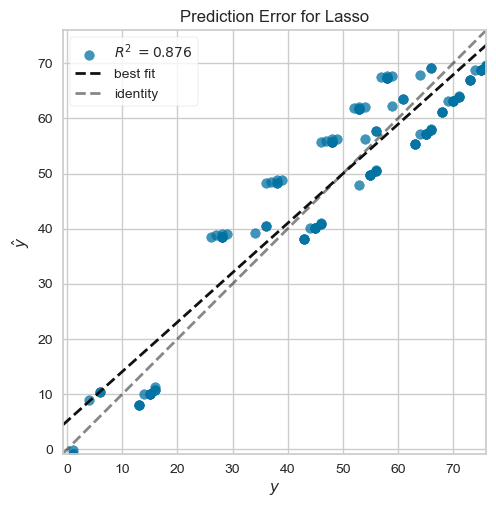

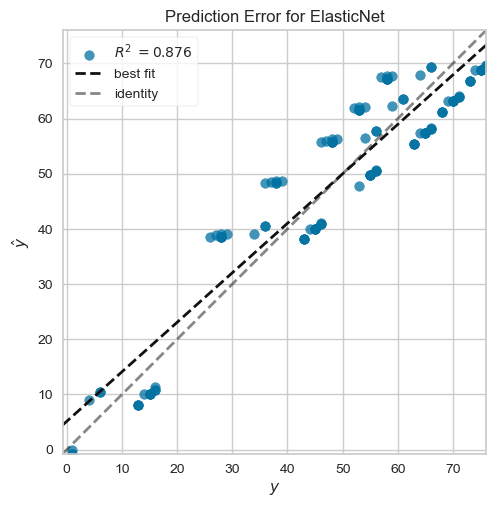

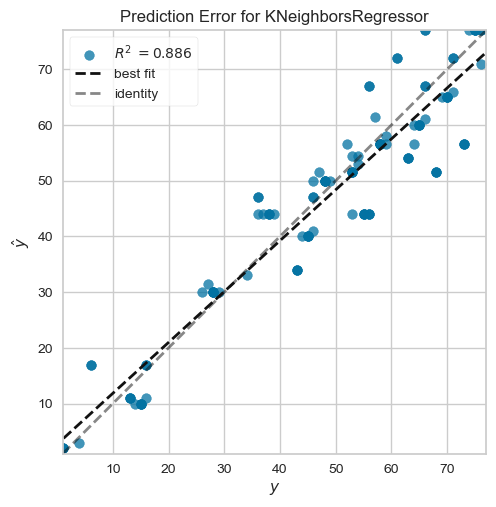

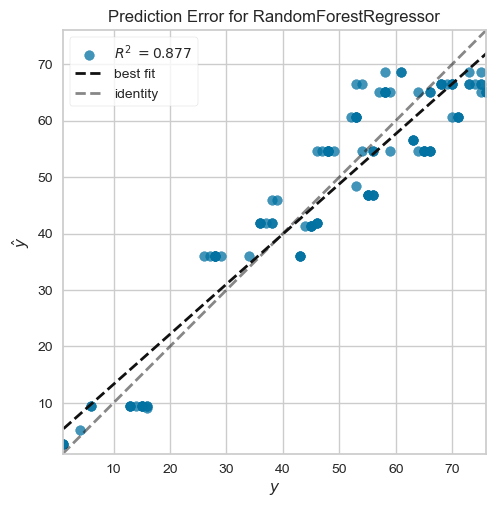

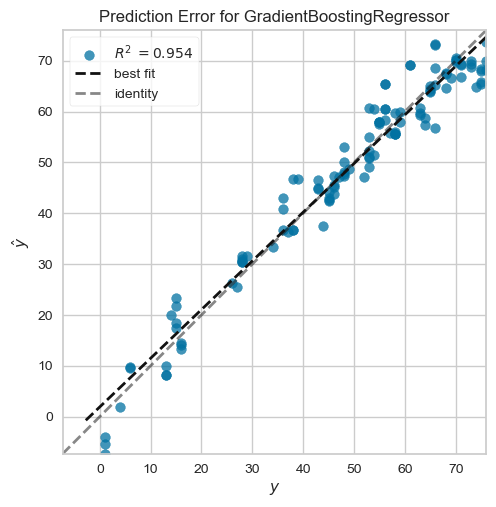

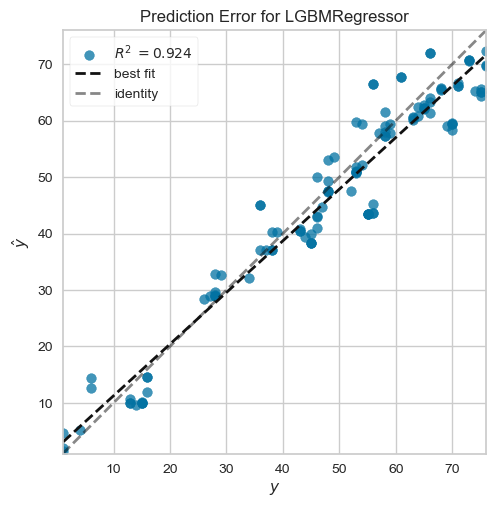

In [11]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_en, plot='error')
plot_model(tuned_knn, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_gbr, plot='error')
plot_model(tuned_lgbm, plot='error')
# plot_model(tuned_ada, plot='error')
# plot_model(tuned_cat, plot='error')
# plot_model(tuned_omp, plot='error')
# plot_model(tuned_huber, plot='error')

In [12]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_en = finalize_model(tuned_en)
final_knn = finalize_model(tuned_knn)
final_rfr = finalize_model(tuned_rfr)
final_gbr = finalize_model(tuned_gbr)
final_lgbm = finalize_model(tuned_lgbm)
# final_ada = finalize_model(tuned_ada)
# final_cat = finalize_model(tuned_cat)
# final_omp = finalize_model(tuned_omp)
# final_huber = finalize_model(tuned_huber)

In [13]:
#--テストデータで予測・評価（収穫日30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST.query("Target_Days <= 30"))
print("KNN")
pred_knn = predict_model(final_knn, data=TEST.query("Target_Days <= 30"))
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST.query("Target_Days <= 30"))
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST.query("Target_Days <= 30"))
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,3.6056,20.0729,4.4803,0.4970,0.3812,0.4721


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,3.5943,19.5745,4.4243,0.5095,0.3918,0.4659


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,7.7818,78.1674,8.8412,-0.9588,1.0214,1.1318


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,4.8900,46.3600,6.8088,-0.1618,0.5336,0.4336


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [14]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST)
print("KNN")
pred_knn = predict_model(final_knn, data=TEST)
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST)
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST)
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST)
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST)
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,5.7993,54.6807,7.3946,0.8961,0.2724,0.2668


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,5.7822,54.2352,7.3645,0.8969,0.2784,0.2640


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,7.3811,77.8035,8.8206,0.8522,0.6685,0.5404


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,6.1217,57.5433,7.5857,0.8907,0.3601,0.2496


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [15]:
#--Lasso回帰の回帰係数をチェック
coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
3,TMP_max,-0.007785
5,GSR,-0.050832
7,TMP_GDD10,0.009780
8,TmulGSR,0.004380
19,TmulGSR_05,-0.015815
46,TmulGSR_20,0.001126
51,APCPRA_25,0.020232
61,GSR_30,-0.041604
69,remain_days,0.235908
70,Intercept,72.956297


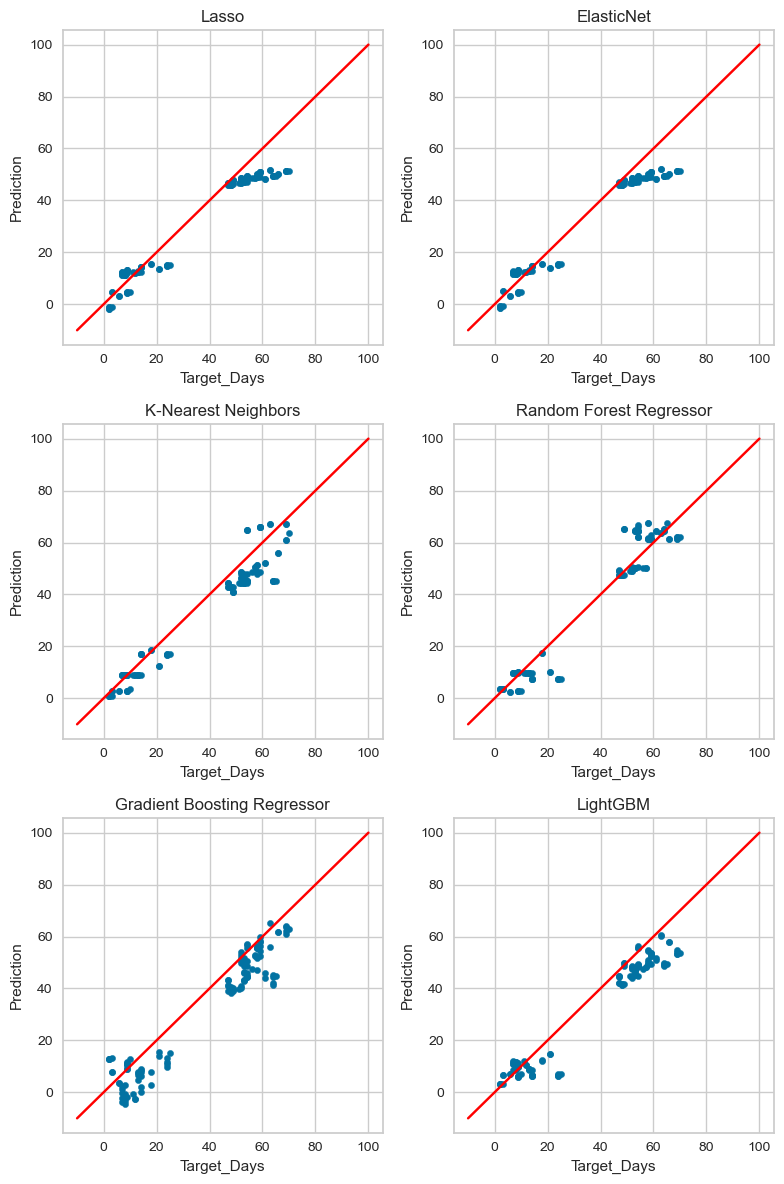

In [16]:
#--予測結果の散布図表示
result = [pred_lasso, pred_en, pred_knn, pred_rfr, pred_gbr, pred_lgbm] #, pred_cat
model_names = ['Lasso', 'ElasticNet', 'K-Nearest Neighbors', 'Random Forest Regressor', 'Gradient Boosting Regressor', 'LightGBM'] #, 'CatBoost'

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,100], [-10,100], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,4.60084,5.364363,0.945321,0.357011


,MAE,RMSE,R2,MAPE
0,5.030612,5.765007,0.16714,0.759464


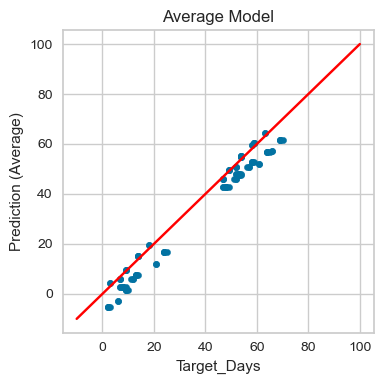

In [17]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,100], [-10,100], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [18]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}_ex"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/kayano1_lasso_model")
save_model(final_en, f"{save_dir}/kayano1_en_model")
save_model(final_knn, f"{save_dir}/kayano1_knn_model")
save_model(final_rfr, f"{save_dir}/kayano1_rfr_model")
save_model(final_gbr, f"{save_dir}/kayano1_gbr_model")
save_model(final_lgbm, f"{save_dir}/kayano1_lgbm_model")
# save_model(final_ada, f"{save_dir}/kayano1_ada_model")
# save_model(final_cat, f"{save_dir}/kayano1_cat_model")
# save_model(final_omp, f"{save_dir}/kayano1_omp_model")
# save_model(final_huber, f"{save_dir}/kayano1_huber_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'TMP_mea',
                                              'TMP_max', 'APCPRA', 'GSR',
                                              'TMP_GDD0', 'TMP_GDD10', 'TmulGSR',
                                              'RA_days', 'RH_ave', 'TMP_mea_jan',
                                              'TMP_mea_feb', 'TMP_mea_05',
                                              'TMP_max_05', 'APCPRA_05',
                                              'GSR_05', 'TMP_GDD0_05',
                                              'TMP_GDD10_05', 'TmulGSR_05',
                                              'RA_days_05', 'RH_ave_05',
                                              'TMP_mea_10',...
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('clean_column_names'

## モデル学習（二番茶）
- PyCaretを用いたMLモデルの学習を行う

In [7]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data2)

#--茶の場合は一番茶・二番茶ともに2025年を含めて3年分しか無いため、CVをするためには2024年をテストデータにできない
# #--2024年をテストデータとする場合、2025年は除外しておく
# df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [8]:
#--全ての年度に共通する品種を抽出
exist_kind = (df_ml
    .groupby('品種')['年度']
    .nunique()
    .loc[lambda x: x == df_ml['年度'].nunique()]
    .index
    .tolist()
)
print(f'全年度共通の品種数: {len(exist_kind)}')
print(f'品種リスト: {exist_kind}')

全年度共通の品種数: 6
品種リスト: ['おくみどり', 'おくゆたか', 'さやまかおり', 'つゆひかり', 'ふうしゅん', 'やぶきた']


In [9]:
### 追加の前処理 ###
#--すべての年度に存在する品種のみを対象とする
# （一番茶はすべて該当するが、二番茶は該当しない品種がある）
df_ml = df_ml.query("品種 in @exist_kind").reset_index(drop=True)

#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
# test_year = 2024
test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['品種','圃場名','年度'])
        .groupby('品種')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['品種','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日数']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [ ]:
### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 
    'TMP_mea', 'APCPRA', 'GSR', 'TMP_GDD0', 'TMP_GDD10', 'TmulGSR', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'GSR_05', 'TMP_GDD0_05', 'TMP_GDD10_05', 'TmulGSR_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'GSR_10', 'TMP_GDD0_10', 'TMP_GDD10_10', 'TmulGSR_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'GSR_15', 'TMP_GDD0_15', 'TMP_GDD10_15', 'TmulGSR_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'GSR_20', 'TMP_GDD0_20', 'TMP_GDD10_20', 'TmulGSR_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'GSR_25', 'TMP_GDD0_25', 'TMP_GDD10_25', 'TmulGSR_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'GSR_30', 'TMP_GDD0_30', 'TMP_GDD10_30', 'TmulGSR_30', 'RA_days_30',
    'TMP_mea_jan', 'TMP_mea_feb',
    'grow_days_mean', 'grow_days_std', 'remain_days',
    'TMP_max', 'RH_ave', 
    'TMP_max_05', 'RH_ave_05', 'TMP_max_10', 'RH_ave_10', 
    'TMP_max_15', 'RH_ave_15', 'TMP_max_20', 'RH_ave_20', 
    'TMP_max_25', 'RH_ave_25', 'TMP_max_30', 'RH_ave_30',  
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

# categorical_cols = ['planting_month']
# for col in categorical_cols:
#     df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 70, Ignore cols: 106
Train samples: 249, Test samples: 199


In [23]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    # categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [24]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
# best = compare_models()

In [25]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--ElasticNetモデル作成
print("ElasticNet")
model_en = create_model('en')

#--KNNモデル作成
print("KNN")
model_knn = create_model('knn')

#--Random Forest Regressorモデル作成
print("Random Forest Regressor")
model_rfr = create_model('rf')

#--GBRモデル作成
print("Gradient Boosting Regressor")
model_gbr = create_model('gbr')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

# #--CatBoostモデル作成
# print("CatBoost")
# model_cat = create_model('catboost')
# #--AdaBoost Regressorモデル作成
# print("AdaBoost Regressor")
# model_ada = create_model('ada')
# #--OMPモデル作成
# print("Orthogonal Matching Pursuit")
# model_omp = create_model('omp')
# #--Huber回帰モデル作成
# print("Huber回帰")
# model_huber = create_model('huber')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.4986,18.7431,4.3293,0.9850,0.1156,0.0754
1,7.4095,81.4320,9.0240,0.9650,0.7879,1.6349
Mean,5.4541,50.0875,6.6766,0.9750,0.4517,0.8551
Std,1.9554,31.3445,2.3473,0.0100,0.3361,0.7798


ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.6890,23.2882,4.8258,0.9814,0.1315,0.0658
1,8.4867,107.6722,10.3765,0.9537,0.8451,1.8882
Mean,6.0878,65.4802,7.6012,0.9676,0.4883,0.9770
Std,2.3989,42.1920,2.7754,0.0139,0.3568,0.9112


KNN


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.4431,129.2450,11.3686,0.8969,0.1947,0.1614
1,9.2497,115.7110,10.7569,0.9502,0.8259,1.8772
Mean,9.3464,122.4780,11.0628,0.9236,0.5103,1.0193
Std,0.0967,6.7670,0.3058,0.0267,0.3156,0.8579


Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,17.0929,466.4488,21.5974,0.6279,0.3044,0.2301
1,12.9087,273.6684,16.5429,0.8823,1.0784,3.3870
Mean,15.0008,370.0586,19.0702,0.7551,0.6914,1.8085
Std,2.0921,96.3902,2.5272,0.1272,0.3870,1.5785


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.6369,137.5208,11.7269,0.8903,0.3942,0.1967
1,10.5779,136.9704,11.7034,0.9411,0.8307,1.8858
Mean,10.1074,137.2456,11.7152,0.9157,0.6124,1.0412
Std,0.4705,0.2752,0.0117,0.0254,0.2183,0.8446


In [26]:
#--ハイパーパラメータチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("ElasticNet")
tuned_en = tune_model(model_en, n_iter=50, optimize='MAE')
print("KNN")
tuned_knn = tune_model(model_knn, n_iter=50, optimize='MAE')
print("Random Forest Regressor")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("Gradient Boosting Regressor")
tuned_gbr = tune_model(model_gbr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
# print("CatBoost")
# tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')
# print("AdaBoost Regressor")
# tuned_ada = tune_model(model_ada, n_iter=50, optimize='MAE')
# print("Orthogonal Matching Pursuit")
# tuned_omp = tune_model(model_omp, n_iter=50, optimize='MAE')
# print("Huber回帰")
# tuned_huber = tune_model(model_huber, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.1390,32.6094,5.7105,0.9740,0.1381,0.0816
1,3.5506,19.2331,4.3856,0.9917,0.3148,0.3314
Mean,3.8448,25.9212,5.0480,0.9829,0.2264,0.2065
Std,0.2942,6.6881,0.6625,0.0089,0.0884,0.1249


Fitting 2 folds for each of 50 candidates, totalling 100 fits
ElasticNet


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5.0394,35.4762,5.9562,0.9717,0.2246,0.1618
1,2.8280,11.8028,3.4355,0.9949,0.3899,0.4686
Mean,3.9337,23.6395,4.6959,0.9833,0.3072,0.3152
Std,1.1057,11.8367,1.2603,0.0116,0.0827,0.1534


Fitting 2 folds for each of 50 candidates, totalling 100 fits
KNN


...

Fitting 2 folds for each of 50 candidates, totalling 100 fits
Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,6.3977,66.8900,8.1786,0.9466,0.1953,0.1262
1,11.5679,166.0289,12.8852,0.9286,0.9055,2.2652
Mean,8.9828,116.4594,10.5319,0.9376,0.5504,1.1957
Std,2.5851,49.5694,2.3533,0.0090,0.3551,1.0695


Fitting 2 folds for each of 50 candidates, totalling 100 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,10.7598,173.8834,13.1865,0.8613,0.4927,0.2206
1,8.5640,103.1765,10.1576,0.9556,0.7813,1.6662
Mean,9.6619,138.5300,11.6720,0.9085,0.6370,0.9434
Std,1.0979,35.3534,1.5145,0.0472,0.1443,0.7228


Fitting 2 folds for each of 50 candidates, totalling 100 fits


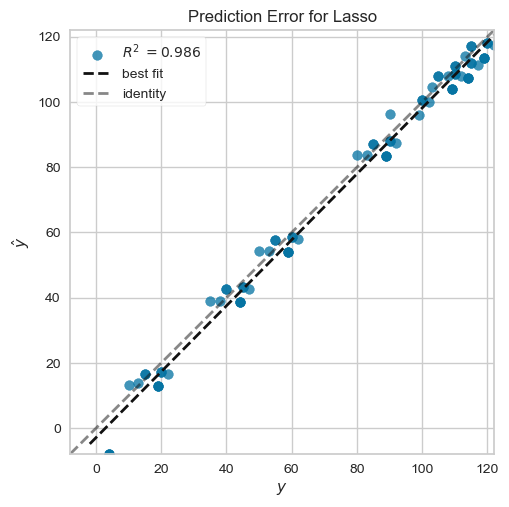

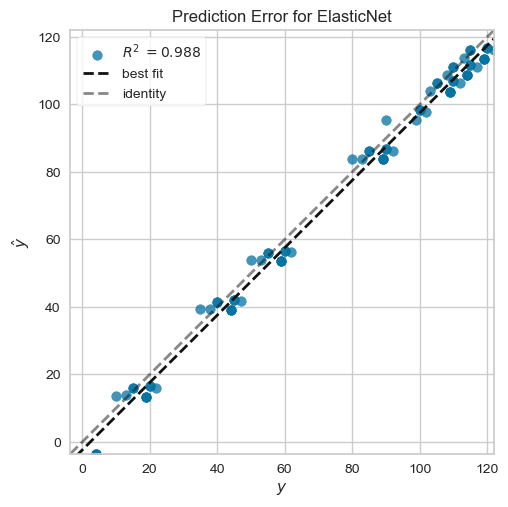

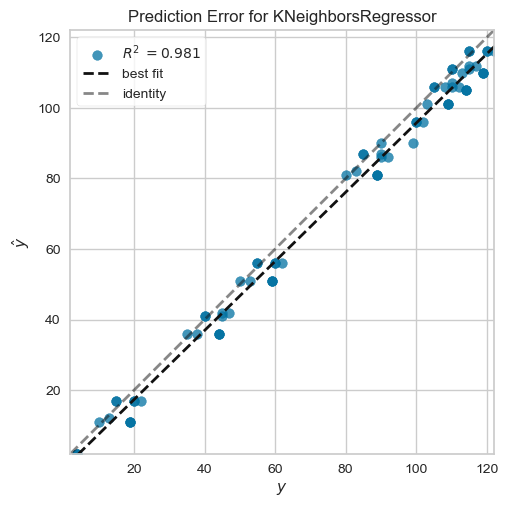

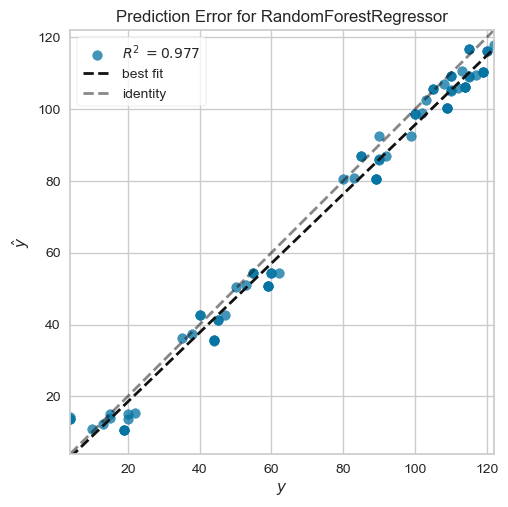

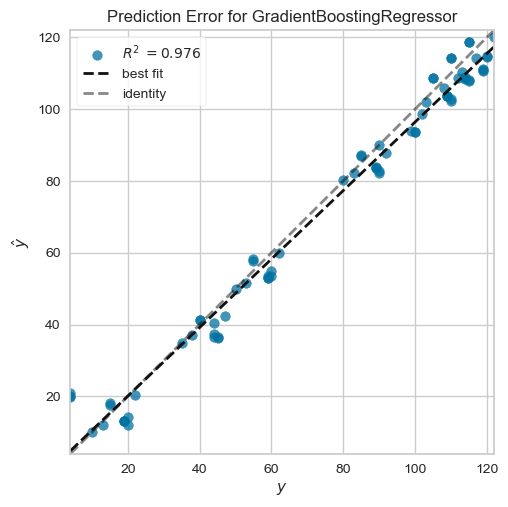

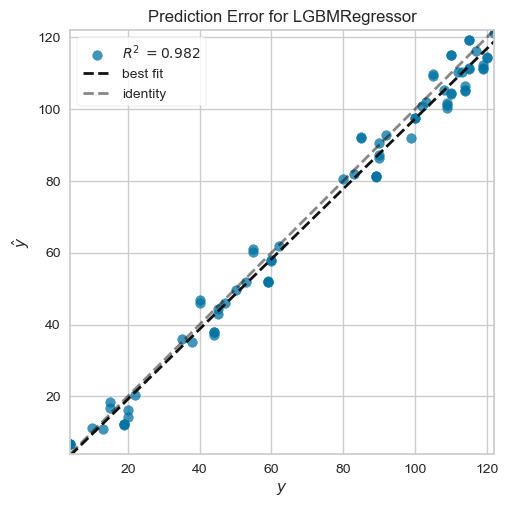

In [27]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_en, plot='error')
plot_model(tuned_knn, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_gbr, plot='error')
plot_model(tuned_lgbm, plot='error')
# plot_model(tuned_ada, plot='error')
# plot_model(tuned_cat, plot='error')
# plot_model(tuned_omp, plot='error')
# plot_model(tuned_huber, plot='error')

In [28]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_en = finalize_model(tuned_en)
final_knn = finalize_model(tuned_knn)
final_rfr = finalize_model(tuned_rfr)
final_gbr = finalize_model(tuned_gbr)
final_lgbm = finalize_model(tuned_lgbm)
# final_ada = finalize_model(tuned_ada)
# final_cat = finalize_model(tuned_cat)
# final_omp = finalize_model(tuned_omp)
# final_huber = finalize_model(tuned_huber)

In [29]:
#--テストデータで予測・評価（収穫日30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST.query("Target_Days <= 30"))
print("KNN")
pred_knn = predict_model(final_knn, data=TEST.query("Target_Days <= 30"))
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST.query("Target_Days <= 30"))
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST.query("Target_Days <= 30"))
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,2.7918,13.6944,3.7006,0.8492,0.4409,0.3550


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,2.8313,9.7635,3.1247,0.8925,0.4772,0.7363


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,3.9599,29.5218,5.4334,0.6750,0.5508,0.6619


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.4846,15.2320,3.9028,0.8323,0.4224,0.5758


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [30]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("ElasticNet")
pred_en = predict_model(final_en, data=TEST)
print("KNN")
pred_knn = predict_model(final_knn, data=TEST)
print("Random Forest Regressor")
pred_rfr = predict_model(final_rfr, data=TEST)
print("Gradient Boosting Regressor")
pred_gbr = predict_model(final_gbr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
# print("AdaBoost Regressor")
# pred_ada = predict_model(final_ada, data=TEST)
# print("CatBoost")
# pred_cat = predict_model(final_cat, data=TEST)
# print("Orthogonal Matching Pursuit")
# pred_omp = predict_model(final_omp, data=TEST)
# print("Huber回帰")
# pred_huber = predict_model(final_huber, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,3.4523,19.0862,4.3688,0.9844,0.2731,0.1688


ElasticNet


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Elastic Net,3.2373,13.3676,3.6562,0.9891,0.2924,0.3029


KNN


...

Gradient Boosting Regressor


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,3.8075,24.5484,4.9546,0.9800,0.3406,0.2847


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,3.4784,17.1352,4.1395,0.9860,0.2620,0.2471


[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [31]:
#--Lasso回帰の回帰係数をチェック
coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
2,TMP_mea,-0.035770
3,TMP_max,-0.004892
4,APCPRA,-0.002763
5,GSR,-0.007421
6,TMP_GDD0,0.001209
7,TMP_GDD10,0.076481
8,TmulGSR,-0.002022
15,APCPRA_05,-0.002980
16,GSR_05,0.004699
19,TmulGSR_05,0.028859


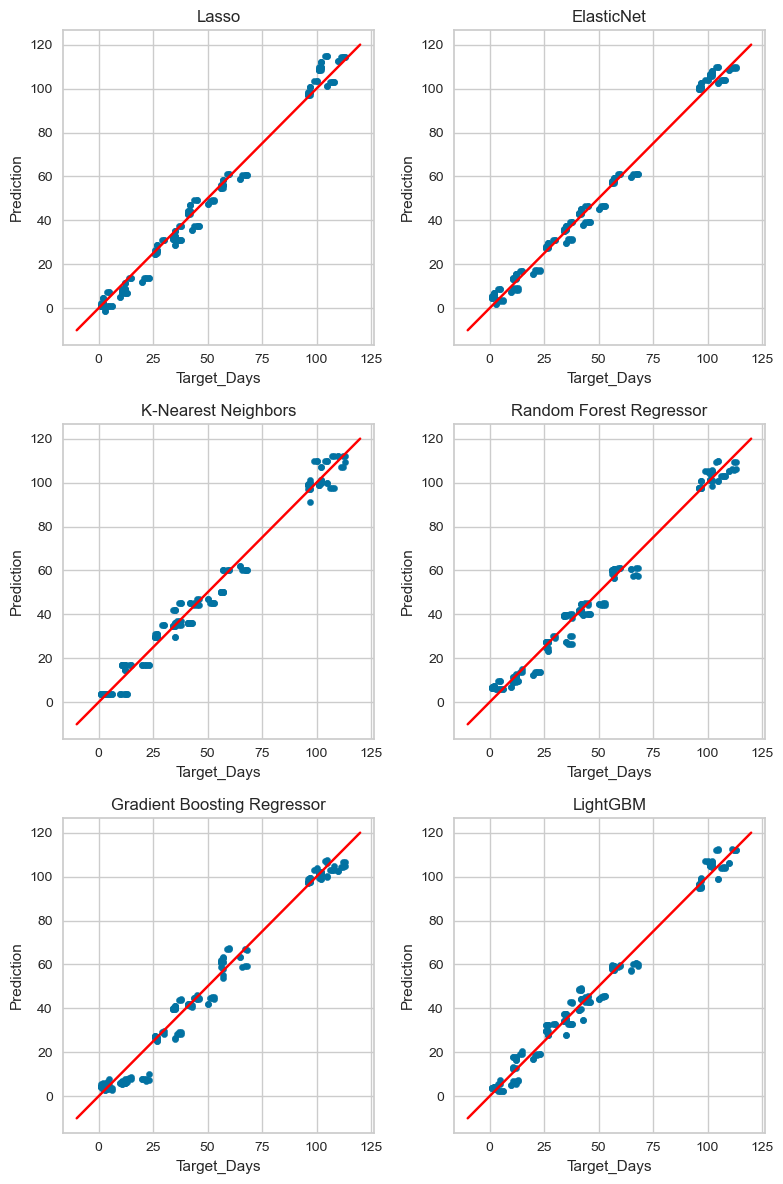

In [32]:
#--予測結果の散布図表示
result = [pred_lasso, pred_en, pred_knn, pred_rfr, pred_gbr, pred_lgbm] #, pred_cat
model_names = ['Lasso', 'ElasticNet', 'K-Nearest Neighbors', 'Random Forest Regressor', 'Gradient Boosting Regressor', 'LightGBM'] #, 'CatBoost'

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,120], [-10,120], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,2.329648,2.865967,0.993307,0.158663


,MAE,RMSE,R2,MAPE
0,2.3,2.852484,0.910417,0.366511


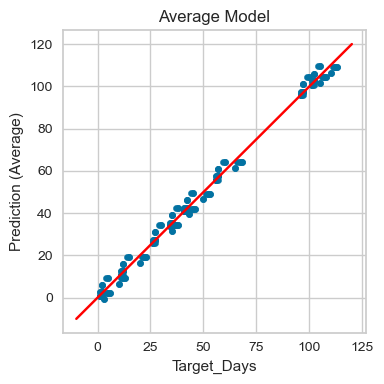

In [33]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,120], [-10,120], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [34]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}_ex"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/kayano2_lasso_model")
save_model(final_en, f"{save_dir}/kayano2_en_model")
save_model(final_knn, f"{save_dir}/kayano2_knn_model")
save_model(final_rfr, f"{save_dir}/kayano2_rfr_model")
save_model(final_gbr, f"{save_dir}/kayano2_gbr_model")
save_model(final_lgbm, f"{save_dir}/kayano2_lgbm_model")
# save_model(final_ada, f"{save_dir}/kayano2_ada_model")
# save_model(final_cat, f"{save_dir}/kayano2_cat_model")
# save_model(final_omp, f"{save_dir}/kayano2_omp_model")
# save_model(final_huber, f"{save_dir}/kayano2_huber_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'TMP_mea',
                                              'TMP_max', 'APCPRA', 'GSR',
                                              'TMP_GDD0', 'TMP_GDD10', 'TmulGSR',
                                              'RA_days', 'RH_ave', 'TMP_mea_jan',
                                              'TMP_mea_feb', 'TMP_mea_05',
                                              'TMP_max_05', 'APCPRA_05',
                                              'GSR_05', 'TMP_GDD0_05',
                                              'TMP_GDD10_05', 'TmulGSR_05',
                                              'RA_days_05', 'RH_ave_05',
                                              'TMP_mea_10',...
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('clean_column_names'

# END